<a href="https://colab.research.google.com/github/Moquiuti/NLP/blob/main/fun%C3%A7%C3%A3o_para_visualizar_a_frequ%C3%AAncia_de_palavras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk import tokenize
from nltk.probability import FreqDist

def grafico_frequencia(df, coluna_texto, quantidade):
    textos = df[coluna_texto].dropna().astype(str)

    todas_palavras = ' '.join(textos)

    token_espaco = tokenize.WhitespaceTokenizer()
    tokens = token_espaco.tokenize(todas_palavras)

    frequencia = FreqDist(tokens)

    df_frequencia = pd.DataFrame(
        frequencia.items(),
        columns=['Palavra', 'Frequência']
    )

    df_frequencia = df_frequencia.sort_values(
        'Frequência',
        ascending=False
    ).head(quantidade)

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=df_frequencia,
        x='Palavra',
        y='Frequência'
    )

    plt.title(f'{quantidade} palavras mais frequentes')
    plt.xlabel('Palavra')
    plt.ylabel('Frequência')
    plt.xticks(rotation=45)
    plt.show()

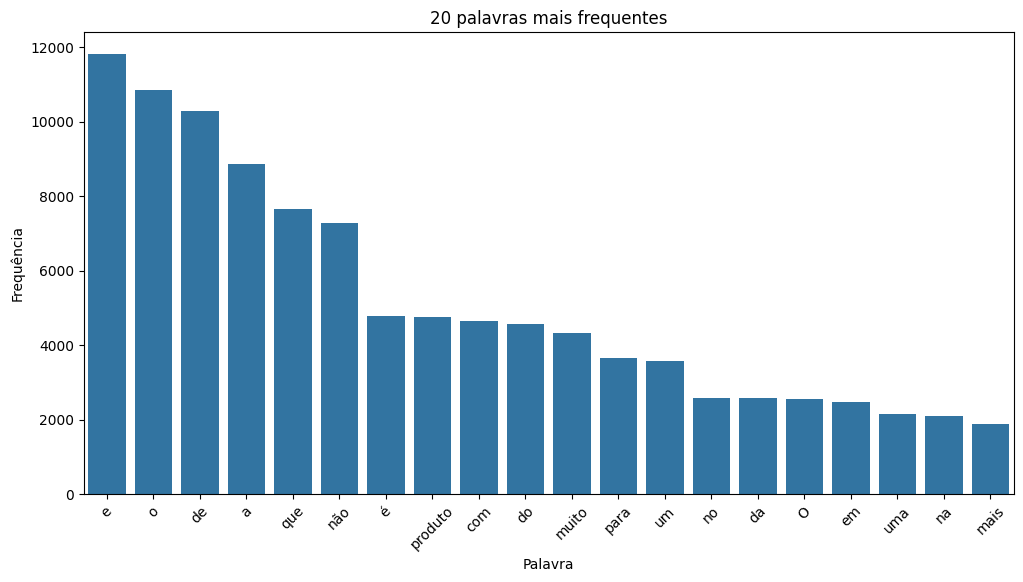

In [5]:
import pandas as pd

df = pd.read_csv('dataset_avaliacoes.csv')
df.head()

grafico_frequencia(df, 'avaliacao', 20)